# **1.- Importar los datos**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset_car_seats.csv')
df.head(10)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


# **2.- Crear ETL y transformar los datos**

Se requiere que las columnas **income, advertising, compprice y price** se multipliquen por el valor que tiene el peso chileno respecto al dolar. Para eso se debe usar la api

https://cl.dolarapi.com/v1/cotizaciones/usd.

In [3]:
import requests
import pandas as pd


# 1. Definir la URL de la API
url_dolar_api = "https://mindicador.cl/api"

# 2. Hacer la petición GET
respuesta = requests.get(url_dolar_api)

# 3. Validar y procesar la respuesta
if respuesta.status_code == 200:
    datos = respuesta.json()

    # Extraer variables clave
    valor_compra = datos.get("dolar")
    print(valor_compra['valor'])
else:
    print(f"Error al conectar con DolarAPI: {respuesta.status_code}")


915.58


In [4]:
df_valor_income = (df['Income'] * valor_compra['valor']).round()
df_valor_advertising = (df['Advertising'] * valor_compra['valor']).round()
df_valor_compprice = (df['CompPrice'] * valor_compra['valor']).round()
df_valor_price = (df['Price'] * valor_compra['valor']).round()

In [5]:
df_transformado = df.copy()
df_transformado['Income'] = df_valor_income
df_transformado['Advertising'] = df_valor_advertising
df_transformado['CompPrice'] = df_valor_compprice
df_transformado['Price'] = df_valor_price
df_transformado.head(10)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,126350.0,66837.0,10071.0,276,109870.0,Bad,42,17,Yes,Yes
1,1,11.22,101629.0,43948.0,14649.0,260,75993.0,Good,65,10,Yes,Yes
2,2,10.06,103461.0,32045.0,9156.0,269,73246.0,Medium,59,12,Yes,Yes
3,3,7.40,107123.0,91558.0,3662.0,466,88811.0,Medium,55,14,Yes,Yes
4,4,4.15,129097.0,58597.0,2747.0,340,117194.0,Bad,38,13,Yes,No
5,5,10.81,113532.0,103461.0,11903.0,501,65922.0,Bad,78,16,No,Yes
6,6,6.63,105292.0,96136.0,0.0,45,98883.0,Medium,71,15,Yes,No
7,7,11.85,124519.0,74162.0,13734.0,425,109870.0,Good,67,10,Yes,Yes
8,8,6.54,120857.0,100714.0,0.0,108,113532.0,Medium,76,10,No,No
9,9,4.69,120857.0,103461.0,0.0,131,113532.0,Medium,76,17,No,Yes


Como podemos ver el punto 2 ha quedado cumplido debido a que las columnas que anteriormente se visualizaban en dolares ahora estan multiplicadas por el valor que tiene el dolar el día en que se ejecute la celda. Ahora las columnas anteriormente indicadas, expresan sus valores en **(MILES DE PESOS)**

## **3.- Análisis exploratorio de los datos**

Una vez ya cumplido el requisito de transformación de los datos requerimos analizar los datos.

Para mayor comprensión de los posteriores puntos debemos comprender a qué pertenece este dataset y qué expresa cada variable

El estudio corresponde a una investigación que requiere averiguar en que tiendas ha sido un exito la venta de un producto especifico que son sillas de niños en autos. Suponemos este estudio se origina del fabricante de estas sillas, los cuales han exportado su producto a todas las tiendas que son detalladas en el dataset. Su fin último es medir su éxito a traves de una nueva variable que identifique las ventas de una tienda como "bajas" (0) o "altas" (0) según un criterio que posteriormente será desarrollado.

Qué expresa cada variable:
- IdTienda: Númerico [secuencial] Identifica la tienda que se expresa en la fila.
- sales: Númerico [miles de unidades] Cantidad de sillas vendidas
- CompPrice: Númerico [miles de pesos chilenos] Precio que cobra el competidor en esa ubicación. Se le agregan 3 ceros extra para pasar a peso chilenos común.
- Income: Númerico [miles de pesos chilenos] Nivel de ingreso de la comunidad.
- Advertising: Númerico [miles de pesos chilenos] Presupuesto local de publicidad de la empresa.
- Population: Númerico [miles de personas] Tamaño de la población regional.
- Price: Númerico [miles de pesos chilenos] Precio que cobra la empresa por las sillas en esa tienda.
- ShelveLoc: Categórica [no aplica] Calidad de la ubicación en la estantería. Se clasifica en niveles: Bad, Medium, Good.
- Age: Númerico [años] edad promedio de la población local.
- Education: Númerico [calificación] nivel educativo promedio en la comunidad.
- Urban: Categórico [no aplica] Factor binario (Yes/No) que indica si la tienda está en zona urbana.
- US: Categórico [no aplica] Factor binario (Yes/No) que indica si la tienda está en EE.UU. o no.

In [6]:
#renombrar la primera columna a id_venta
df_transformado.rename(columns={'Unnamed: 0': 'IdTienda'}, inplace=True)
df_transformado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IdTienda     400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    float64
 3   Income       400 non-null    float64
 4   Advertising  400 non-null    float64
 5   Population   400 non-null    int64  
 6   Price        400 non-null    float64
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
dtypes: float64(5), int64(4), object(3)
memory usage: 37.6+ KB


In [7]:
df_transformado.describe()

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,7.496325,114424.610000,62861.447500,6074.89000,264.840000,106019.612500,53.322500,13.900000
std,115.614301,2.824115,14039.966175,25623.458533,6088.94878,147.376436,21677.867557,16.200297,2.620528
min,0.000000,0.000000,70500.000000,19227.000000,0.00000,10.000000,21974.000000,25.000000,10.000000
25%,99.750000,5.390000,105292.000000,39141.000000,0.00000,139.000000,91558.000000,39.750000,12.000000
50%,199.500000,7.490000,114448.000000,63175.000000,4578.00000,272.000000,107123.000000,54.500000,14.000000
75%,299.250000,9.320000,123603.000000,83318.000000,10987.00000,398.500000,119941.000000,66.000000,16.000000
max,399.000000,16.270000,160226.000000,109870.000000,26552.00000,509.000000,174876.000000,80.000000,18.000000


In [8]:
##Mostramos estadística descriptiva de las variables categóricas
df_transformado.describe(include=['O'])
#data.describe(include=object)

,ShelveLoc,Urban,US
count,400,400,400
unique,3,2,2
top,Medium,Yes,Yes
freq,219,282,258


In [9]:
##Mostramos cantidad de filas y columnas del dataset
df_transformado.shape

(400, 12)

In [10]:
df_transformado.head(1)

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.5,126350.0,66837.0,10071.0,276,109870.0,Bad,42,17,Yes,Yes


Ya con este analisis breve y básico descartamos el proceso de buscar nulos e imputarlos. Debido a que según el shape la forma del dataset es 400, 12 y la cantidad de count en cada variable es equivalente al número de filas.

Aparte de ya notar cierta tendencia en muchas variables. Que mostraremos y analizaremos en graficos posteriores

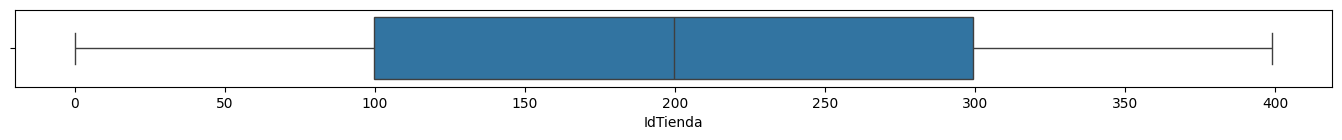

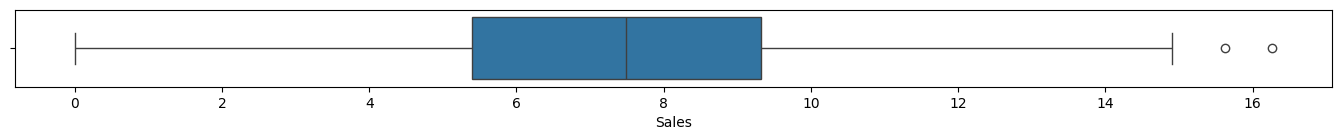

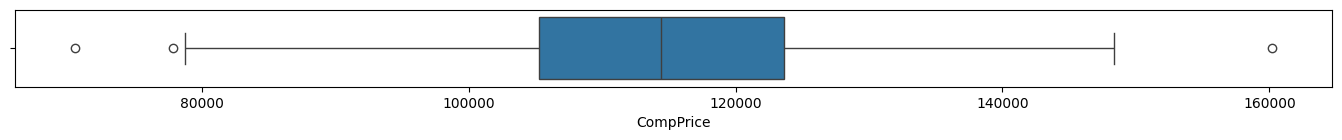

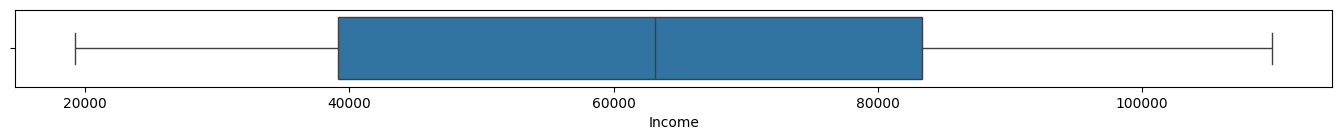

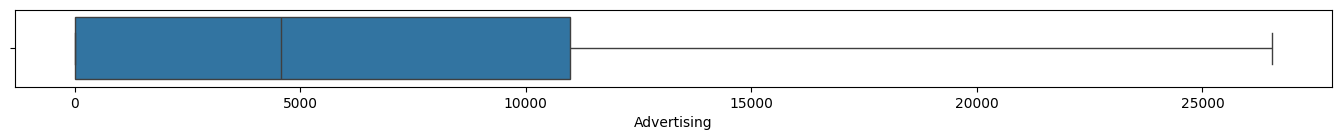

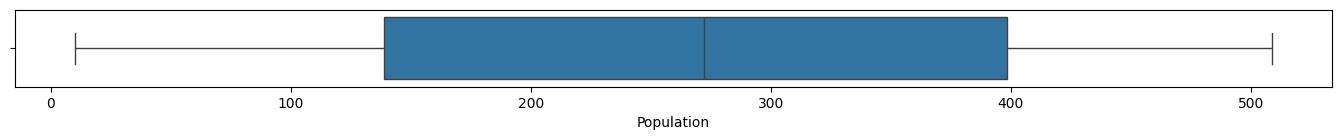

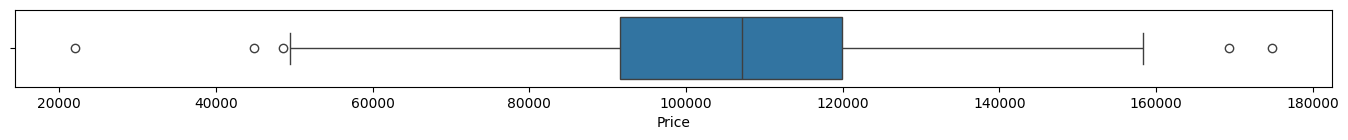

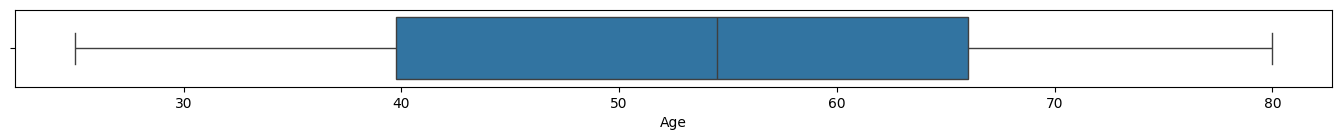

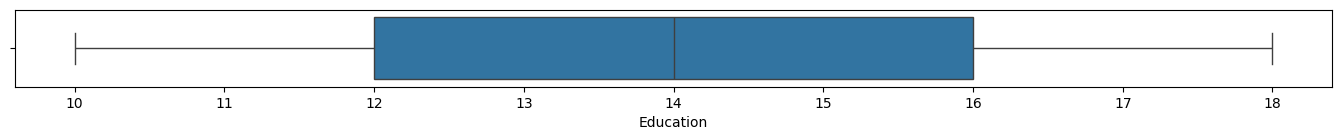

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## Creamos diagramas de caja para las variables numéricas para determinar outliers
num_cols=df_transformado.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df_transformado[num_cols], x=col)

Como podemos ver en estos boxplot, los outliers son pocos pero importantes para el contexto del negocio. Debido a que para un analisis estadistico necesitamos dejar fuera estas tiendas las borraremos del dataset que se continuará trabajando.

Sin embargo los valores tienen una importancia profunda en cuanto a una posible estrategia o filosofía de negocio que premie o se preocupe de los extremos. Por lo tanto se buscarán valores por la metodología de los intercuartiles.

In [12]:
import numpy as np
import pandas as pd

## El Rango Intercuartílico (IQR) es una técnica robusta para detectar valores extremos
# Nº de Outliers usando rango IQR
outliers = {}
outliers_above = {}
outliers_below = {}
df_outliers_list = [] # Lista para almacenar DataFrames de outliers

# Nos aseguramos antes de inicar num_cols que solo sean numericos
num_cols = df_transformado.select_dtypes(include='number').columns

for col in num_cols:
  Q1 = np.percentile(df_transformado[col], 25)
  Q3 = np.percentile(df_transformado[col], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Identificar outliers por debajo y por encima
  outliers_low = df_transformado[df_transformado[col] < lower_bound]
  outliers_high = df_transformado[df_transformado[col] > upper_bound]

  outliers_below[col] = outliers_low['IdTienda'].tolist()
  outliers_above[col] = outliers_high['IdTienda'].tolist()
  outliers[col]= len(outliers_low) + len(outliers_high)

  # Guardar outliers en la lista con todas las variables originales y la información del outlier
  if not outliers_low.empty:
      temp_df_low = outliers_low.copy()
      temp_df_low['Columna'] = col
      temp_df_low['Valor_Outlier'] = temp_df_low[col] # El valor específico que es un outlier
      temp_df_low['Tipo_Outlier'] = 'Por Debajo'
      df_outliers_list.append(temp_df_low)

  if not outliers_high.empty:
      temp_df_high = outliers_high.copy()
      temp_df_high['Columna'] = col
      temp_df_high['Valor_Outlier'] = temp_df_high[col] # El valor específico que es un outlier
      temp_df_high['Tipo_Outlier'] = 'Por Encima'
      df_outliers_list.append(temp_df_high)

# Concatenar todos los DataFrames de outliers de la lista
if df_outliers_list:
    df_outliers = pd.concat(df_outliers_list, ignore_index=True)
else:
    df_outliers = pd.DataFrame(columns=list(df_transformado.columns) + ['Columna', 'Valor_Outlier', 'Tipo_Outlier'])

print("Recuento total de outliers por columna:", outliers)
print("IDs de outliers por debajo del límite:", outliers_below)
print("IDs de outliers por encima del límite:", outliers_above)

Recuento total de outliers por columna: {'IdTienda': 0, 'Sales': 2, 'CompPrice': 3, 'Income': 0, 'Advertising': 0, 'Population': 0, 'Price': 5, 'Age': 0, 'Education': 0}
IDs de outliers por debajo del límite: {'IdTienda': [], 'Sales': [], 'CompPrice': [42, 44], 'Income': [], 'Advertising': [], 'Population': [], 'Price': [42, 125, 367], 'Age': [], 'Education': []}
IDs de outliers por encima del límite: {'IdTienda': [], 'Sales': [316, 376], 'CompPrice': [310], 'Income': [], 'Advertising': [], 'Population': [], 'Price': [165, 174], 'Age': [], 'Education': []}


Identificamos lo que ya visualizamos en el boxplot. Lo importante es poder retirar estas id's del dataset. Aparte pudimos guardar estas id's retiradas en un dataset llamado df_outliers. El cual agrega una nueva columna Tipo_Outlier encima del limite o bajo el limite para fines de entendimiento practico.

In [13]:
df_outliers.head(50)

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Columna,Valor_Outlier,Tipo_Outlier
0,316,15.63,111701.0,32961.0,4578.0,369,65922.0,Good,35,10,Yes,Yes,Sales,15.63,Por Encima
1,376,16.27,129097.0,54935.0,17396.0,319,84233.0,Good,44,11,Yes,Yes,Sales,16.27,Por Encima
2,42,10.43,70500.0,63175.0,0.0,25,21974.0,Medium,50,18,Yes,No,CompPrice,70500.00,Por Debajo
3,44,4.16,77824.0,72331.0,5493.0,325,86980.0,Medium,69,13,Yes,Yes,CompPrice,77824.00,Por Debajo
4,310,9.53,160226.0,59513.0,26552.0,419,151986.0,Medium,53,12,Yes,Yes,CompPrice,160226.00,Por Encima
5,42,10.43,70500.0,63175.0,0.0,25,21974.0,Medium,50,18,Yes,No,Price,21974.00,Por Debajo
6,125,9.34,81487.0,71415.0,0.0,181,44863.0,Medium,43,15,No,No,Price,44863.00,Por Debajo
7,367,14.37,86980.0,97051.0,0.0,256,48526.0,Good,52,17,Yes,No,Price,48526.00,Por Debajo
8,165,0.37,134590.0,53104.0,6409.0,100,174876.0,Bad,27,15,Yes,Yes,Price,174876.00,Por Encima
9,174,0.00,127266.0,21974.0,0.0,358,169382.0,Medium,79,15,No,No,Price,169382.00,Por Encima


In [14]:
#eliminamos las columnas en df_transformado que esten en df_outliers para limpiar
df_transformado = df_transformado[~df_transformado['IdTienda'].isin(df_outliers['IdTienda'])]
df_transformado.shape

(391, 12)

In [15]:
df_transformado.duplicated().sum()


np.int64(0)

Ahora que no tenemos outliers, ni nulos, ni duplicados, ni valores faltantes. Podemos crear la nueva columna requerida para medir el exito de una tienda. Esta es binaria y depende solo de sus ventas. Su nombre es HighSales y depende de
- Altas [1] = ventas mayores a 8
- Bajas [0] = ventas menores o iguales a 8

(Recordar que la cantidad de ventas está en miles de unidades)

In [16]:
df_transformado['HighSales'] = np.where(df_transformado['Sales'] > 8, 1, 0)

df_transformado.head()

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,126350.0,66837.0,10071.0,276,109870.0,Bad,42,17,Yes,Yes,1
1,1,11.22,101629.0,43948.0,14649.0,260,75993.0,Good,65,10,Yes,Yes,1
2,2,10.06,103461.0,32045.0,9156.0,269,73246.0,Medium,59,12,Yes,Yes,1
3,3,7.40,107123.0,91558.0,3662.0,466,88811.0,Medium,55,14,Yes,Yes,0
4,4,4.15,129097.0,58597.0,2747.0,340,117194.0,Bad,38,13,Yes,No,0


Al analizar la proporción que generó esta nueva variable en cuanto a su condición es esta:

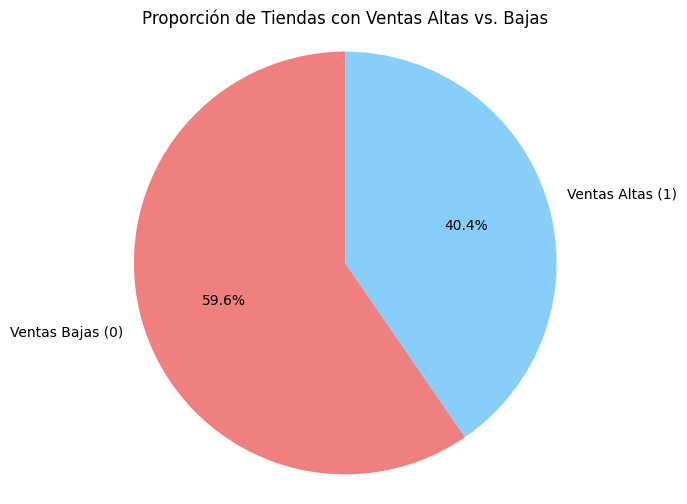

In [17]:
# Obtener el recuento de valores para la variable objetivo 'HighSales'
sales_counts = df_transformado['HighSales'].value_counts()

# Crear el gráfico de torta
plt.figure(figsize=(6, 6))
plt.pie(sales_counts, labels=['Ventas Bajas (0)', 'Ventas Altas (1)'], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Proporción de Tiendas con Ventas Altas vs. Bajas')
plt.axis('equal')
plt.show()

Cabe recalcar la necesidad de un análisis en profundidad que permita discutir si que la nueva variable solo dependa de la cantidad de ventas es suficiente como para juzgar el rendimiento de una empresa al vender el producto. Debido a que se pueden ver casos de empresas que invierten poca cantidad en publicidad y generan muchas ventas y otras que dependen más del contexto métrico de su población y que respecto a estos podrían tener una cantidad de ventas mucho mayor. Siendo posible su evaluación según su contexto y así valorar justamente a cada situación.

<Axes: >

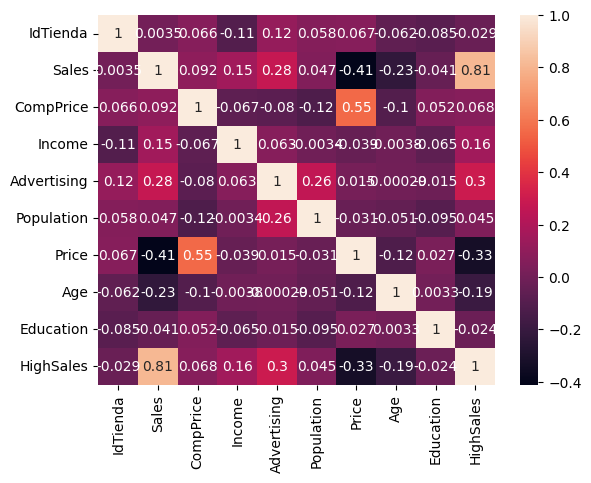

In [18]:
num_cols=df_transformado.select_dtypes(include='number').columns
matriz=df_transformado[num_cols].corr()
sns.heatmap(matriz,annot=True)

Esta matriz de correlación ya nos permite ver ciertas variables que influyen más en las ventas que otras. Se harán notar en estos siguientes gráficos que inspeccionarán la relación entre estas variables

# 4.- Dashboards de ploty dash

### Preparacion para los graficos

Se trabaja con los datos transformados en `df_transformado`. Se crea una copia llamada `df_dash` y algunas variables auxiliares para que los graficos se enfoquen mejor en el analisis de ventas.

In [19]:
# Librerias necesarias para Plotly Dash en Colab.
import sys
!{sys.executable} -m pip install dash dash_bootstrap_components plotly statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 19.5 MB/s eta 0:00:00


In [20]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot
import dash
from dash import Dash, dcc, html
import dash_bootstrap_components as dbc

# Copia de trabajo.
df_dash = df_transformado.copy()

df_dash['NivelVentas'] = np.where(df_dash['HighSales'] == 1, 'Ventas altas', 'Ventas bajas')
df_dash['MargenCompetitivo'] = df_dash['CompPrice'] - df_dash['Price']
df_dash['RangoPrecio'] = pd.qcut(df_dash['Price'], q=5, duplicates='drop')
df_dash['RangoIngreso'] = pd.qcut(df_dash['Income'], q=5, duplicates='drop')
df_dash['RangoEdad'] = pd.cut(df_dash['Age'], bins=[0, 35, 45, 55, 65, 100], labels=['<=35', '36-45', '46-55', '56-65', '66+'])

PALETA = ['#2E86AB', '#F18F01', '#5C946E', '#C73E1D', '#6A4C93', '#00A6A6']
TEMPLATE = 'plotly_white'

def formato_figura(fig, titulo, alto=430):
    fig.update_layout(
        title=titulo,
        template=TEMPLATE,
        height=alto,
        margin=dict(l=45, r=30, t=70, b=55),
        font=dict(family='Arial', size=12),
        title_font=dict(size=18),
        legend_title_text='',
        plot_bgcolor='white',
        paper_bgcolor='white'
    )
    return fig

#### Grafico 1: ventas promedio por ubicacion en estanteria

Este grafico permite comparar el promedio de ventas segun la ubicacion del producto en la estanteria. Se observa si las tiendas con ubicacion Good logran mejores ventas que las categorias Medium y Bad, lo que ayuda a evaluar la importancia de la visibilidad del producto.

In [21]:
ventas_estanteria = (
    df_dash.groupby('ShelveLoc', as_index=False)
    .agg(VentasPromedio=('Sales', 'mean'), Tiendas=('IdTienda', 'count'))
)
ventas_estanteria['ShelveLoc'] = pd.Categorical(ventas_estanteria['ShelveLoc'], categories=['Bad', 'Medium', 'Good'], ordered=True)
ventas_estanteria = ventas_estanteria.sort_values('ShelveLoc')

fig_01 = px.bar(
    ventas_estanteria,
    x='ShelveLoc',
    y='VentasPromedio',
    color='ShelveLoc',
    text='VentasPromedio',
    hover_data=['Tiendas'],
    labels={'ShelveLoc': 'Ubicacion en estanteria', 'VentasPromedio': 'Ventas promedio'},
    color_discrete_sequence=PALETA
)
fig_01.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_01.update_layout(showlegend=False)
fig_01 = formato_figura(fig_01, 'Ventas promedio por ubicacion en estanteria')
iplot(fig_01)

Se observa que la ubicacion del producto influye en las ventas promedio. Las tiendas con estanteria Good presentan mejores resultados que Medium y Bad, por lo que la visibilidad del producto parece ser un factor importante para aumentar las ventas.

#### Grafico 2: distribucion de ventas por ubicacion en estanteria

Este boxplot muestra como se distribuyen las ventas dentro de cada tipo de ubicacion en estanteria. Sirve para identificar diferencias en la mediana, dispersion y posibles valores extremos, permitiendo ver si una mejor ubicacion no solo aumenta el promedio, sino tambien la consistencia de las ventas.

In [22]:
fig_02 = px.box(
    df_dash,
    x='ShelveLoc',
    y='Sales',
    color='ShelveLoc',
    points='outliers',
    category_orders={'ShelveLoc': ['Bad', 'Medium', 'Good']},
    labels={'ShelveLoc': 'Ubicacion en estanteria', 'Sales': 'Ventas'},
    color_discrete_sequence=PALETA
)
fig_02.update_layout(showlegend=False)
fig_02 = formato_figura(fig_02, 'Distribucion de ventas por ubicacion en estanteria')
iplot(fig_02)

El boxplot muestra que las ventas no solo son mayores en Good, sino que tambien tienden a concentrarse en valores mas altos. En cambio, Bad presenta ventas mas bajas en general, lo que refuerza la importancia de una buena ubicacion en estanteria.

#### Grafico 3: relacion entre precio y ventas

Este grafico analiza la relacion entre el precio del producto y las ventas. La tendencia permite observar si precios mas altos se asocian con menores ventas, y el color por ubicacion en estanteria ayuda a ver si una buena posicion puede compensar parcialmente un precio elevado.

In [23]:
fig_03 = px.scatter(
    df_dash,
    x='Price',
    y='Sales',
    color='ShelveLoc',
    trendline='ols',
    hover_data=['IdTienda', 'Advertising', 'Income', 'Urban', 'US'],
    labels={'Price': 'Precio', 'Sales': 'Ventas', 'ShelveLoc': 'Estanteria'},
    color_discrete_sequence=PALETA
)
fig_03 = formato_figura(fig_03, 'Relacion entre precio y ventas')
iplot(fig_03)

La relacion entre precio y ventas muestra una tendencia negativa: cuando el precio aumenta, las ventas tienden a disminuir. Esto indica que el producto puede ser sensible al precio, aunque una buena estanteria puede ayudar a mantener mejores ventas.

#### Grafico 4: ventas promedio por rango de precio

Este grafico agrupa los precios en rangos y muestra la venta promedio de cada grupo. Permite identificar si existe una caida en ventas cuando el producto entra en rangos de precio mas altos, lo cual es util para analizar sensibilidad al precio.

In [24]:
ventas_rango_precio = (
    df_dash.groupby('RangoPrecio', observed=False, as_index=False)
    .agg(VentasPromedio=('Sales', 'mean'), Tiendas=('IdTienda', 'count'))
)
ventas_rango_precio['RangoPrecio'] = ventas_rango_precio['RangoPrecio'].astype(str)

fig_04 = px.line(
    ventas_rango_precio,
    x='RangoPrecio',
    y='VentasPromedio',
    markers=True,
    hover_data=['Tiendas'],
    labels={'RangoPrecio': 'Rango de precio', 'VentasPromedio': 'Ventas promedio'}
)
fig_04.update_traces(line=dict(color='#2E86AB', width=3), marker=dict(size=9, color='#F18F01'))
fig_04.update_xaxes(tickangle=25)
fig_04 = formato_figura(fig_04, 'Ventas promedio por rango de precio')
iplot(fig_04)

Al agrupar los precios, se aprecia que los rangos de precio mas altos tienden a tener menores ventas promedio. Esto confirma que el precio es una variable relevante para explicar el comportamiento de Sales.

#### Grafico 5: publicidad y ventas

Este grafico relaciona la inversion en publicidad con las ventas obtenidas. El tamano de las burbujas representa la poblacion, por lo que permite analizar si mayores niveles de publicidad y mercados mas grandes se asocian con mejores ventas.

In [25]:
fig_05 = px.scatter(
    df_dash,
    x='Advertising',
    y='Sales',
    size='Population',
    color='NivelVentas',
    hover_data=['IdTienda', 'Price', 'ShelveLoc'],
    size_max=35,
    labels={'Advertising': 'Publicidad', 'Sales': 'Ventas', 'Population': 'Poblacion', 'NivelVentas': 'Nivel de ventas'},
    color_discrete_sequence=['#2E86AB', '#F18F01']
)
fig_05 = formato_figura(fig_05, 'Publicidad y ventas considerando poblacion')
iplot(fig_05)

El grafico muestra que mayores niveles de publicidad suelen asociarse con mejores ventas, especialmente en tiendas clasificadas con ventas altas. Tambien se observa que la poblacion puede influir, ya que mercados mas grandes pueden entregar mas oportunidades de venta.

#### Grafico 6: ventas totales por mercado US

Este grafico compara las ventas totales entre tiendas ubicadas en el mercado US y las que no pertenecen a ese mercado. Ayuda a identificar si la presencia en US concentra una mayor cantidad de ventas acumuladas.

In [26]:
ventas_us = (
    df_dash.groupby('US', as_index=False)
    .agg(VentasTotales=('Sales', 'sum'), VentasPromedio=('Sales', 'mean'), Tiendas=('IdTienda', 'count'))
)

fig_06 = px.bar(
    ventas_us,
    x='US',
    y='VentasTotales',
    color='US',
    text='VentasTotales',
    hover_data=['VentasPromedio', 'Tiendas'],
    labels={'US': 'Mercado US', 'VentasTotales': 'Ventas totales'},
    color_discrete_sequence=PALETA
)
fig_06.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig_06.update_layout(showlegend=False)
fig_06 = formato_figura(fig_06, 'Ventas totales por mercado US')
iplot(fig_06)

Las ventas totales permiten comparar el rendimiento acumulado entre tiendas en mercado US y no US. Si el grupo US concentra mas ventas, esto puede indicar que ese mercado tiene mejores condiciones comerciales o mayor respuesta a la publicidad.

#### Grafico 7: ventas promedio por zona urbana y mercado US

Este grafico compara el promedio de ventas considerando dos variables: si la tienda esta en zona urbana y si pertenece al mercado US. Permite analizar si el contexto geografico influye en el rendimiento de ventas.

In [27]:
ventas_zona_us = (
    df_dash.groupby(['Urban', 'US'], as_index=False)
    .agg(VentasPromedio=('Sales', 'mean'), Tiendas=('IdTienda', 'count'))
)

fig_07 = px.bar(
    ventas_zona_us,
    x='Urban',
    y='VentasPromedio',
    color='US',
    barmode='group',
    text='VentasPromedio',
    hover_data=['Tiendas'],
    labels={'Urban': 'Zona urbana', 'US': 'Mercado US', 'VentasPromedio': 'Ventas promedio'},
    color_discrete_sequence=PALETA
)
fig_07.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_07 = formato_figura(fig_07, 'Ventas promedio por zona urbana y mercado US')
iplot(fig_07)

La comparacion muestra que la zona urbana por si sola no siempre explica grandes diferencias, pero al combinarla con mercado US se pueden ver variaciones mas claras. Esto sugiere que el contexto geografico puede influir, aunque no tanto como precio o estanteria.

#### Grafico 8: proporcion de ventas altas y bajas

Este grafico muestra la proporcion de tiendas clasificadas como ventas altas y ventas bajas. Sirve para entender si la mayoria de las tiendas supera o no el umbral definido de ventas, y entrega una vision general del desempeno comercial.

In [28]:
conteo_nivel = df_dash['NivelVentas'].value_counts().reset_index()
conteo_nivel.columns = ['NivelVentas', 'Cantidad']

fig_08 = px.pie(
    conteo_nivel,
    names='NivelVentas',
    values='Cantidad',
    color_discrete_sequence=['#2E86AB', '#F18F01'],
    hole=0.35
)
fig_08.update_traces(textposition='inside', textfont_size=15, textinfo='percent+label')
fig_08.update_layout(showlegend=False)
fig_08 = formato_figura(fig_08, 'Proporcion de tiendas con ventas altas y bajas')
iplot(fig_08)

Este grafico muestra como se divide el dataset segun el criterio de ventas altas. Si la mayor parte queda en ventas bajas, significa que superar el umbral de Sales > 8 no es tan comun y que las tiendas con ventas altas representan un grupo mas destacado.

#### Grafico 9: ventas promedio por ingreso y estanteria

Este mapa de calor cruza rangos de ingreso con ubicacion en estanteria. Permite identificar combinaciones donde las ventas promedio son mayores, por ejemplo si una buena ubicacion en zonas de mayor ingreso mejora el rendimiento.

In [29]:
ventas_ingreso_estanteria = (
    df_dash.groupby(['RangoIngreso', 'ShelveLoc'], observed=False, as_index=False)
    .agg(VentasPromedio=('Sales', 'mean'))
)
ventas_ingreso_estanteria['RangoIngreso'] = ventas_ingreso_estanteria['RangoIngreso'].astype(str)
matriz_ingreso = ventas_ingreso_estanteria.pivot(index='ShelveLoc', columns='RangoIngreso', values='VentasPromedio')
matriz_ingreso = matriz_ingreso.reindex(['Bad', 'Medium', 'Good'])

fig_09 = px.imshow(
    matriz_ingreso,
    text_auto='.2f',
    color_continuous_scale='Blues',
    labels=dict(x='Rango de ingreso', y='Estanteria', color='Ventas promedio')
)
fig_09 = formato_figura(fig_09, 'Ventas promedio por ingreso y estanteria', alto=450)
iplot(fig_09)

El mapa de calor permite ver que la estanteria sigue siendo importante incluso al considerar el ingreso. Las mejores combinaciones suelen aparecer cuando la ubicacion es Good, lo que indica que una buena posicion del producto puede potenciar las ventas en distintos niveles de ingreso.

#### Grafico 10: ventas promedio por rango de edad

Este grafico muestra las ventas promedio segun rangos de edad de la poblacion. Ayuda a observar si ciertos grupos etarios se relacionan con mejores niveles de venta, lo que puede apoyar decisiones de segmentacion.

In [30]:
ventas_edad = (
    df_dash.groupby('RangoEdad', observed=False, as_index=False)
    .agg(VentasPromedio=('Sales', 'mean'), Tiendas=('IdTienda', 'count'))
)

fig_10 = px.bar(
    ventas_edad,
    x='RangoEdad',
    y='VentasPromedio',
    color='RangoEdad',
    text='VentasPromedio',
    hover_data=['Tiendas'],
    labels={'RangoEdad': 'Rango de edad', 'VentasPromedio': 'Ventas promedio'},
    color_discrete_sequence=PALETA
)
fig_10.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_10.update_layout(showlegend=False)
fig_10 = formato_figura(fig_10, 'Ventas promedio por rango de edad')
iplot(fig_10)

Las ventas promedio por edad permiten observar si ciertos grupos etarios se relacionan con mejores resultados. En general, si los rangos de menor edad muestran mejores ventas, podria interpretarse que el producto tiene mejor respuesta en mercados mas jovenes.

#### Grafico 11: margen competitivo y ventas

Este grafico compara las ventas con el margen competitivo, calculado como CompPrice - Price. Si el margen es positivo, significa que el precio de la competencia es mayor que el propio, lo que puede representar una ventaja. Permite analizar si esa ventaja se refleja en mayores ventas.

In [31]:
fig_11 = px.scatter(
    df_dash,
    x='MargenCompetitivo',
    y='Sales',
    color='NivelVentas',
    trendline='ols',
    hover_data=['IdTienda', 'Price', 'CompPrice', 'ShelveLoc'],
    labels={'MargenCompetitivo': 'CompPrice - Price', 'Sales': 'Ventas', 'NivelVentas': 'Nivel de ventas'},
    color_discrete_sequence=['#2E86AB', '#F18F01']
)
fig_11.add_vline(x=0, line_width=1, line_dash='dash', line_color='gray')
fig_11 = formato_figura(fig_11, 'Margen competitivo y ventas')
iplot(fig_11)

El margen competitivo ayuda a analizar si tener un precio propio menor al de la competencia se relaciona con mayores ventas. Cuando el margen es positivo y las ventas aumentan, se puede interpretar que tener ventaja frente al precio de la competencia favorece el rendimiento.

#### Grafico 12: relacion de variables numericas con ventas

Este grafico resume la correlacion entre las variables numericas y las ventas. Permite identificar que factores tienen mayor relacion positiva o negativa con Sales, ayudando a priorizar las variables mas importantes para explicar el comportamiento de ventas.

In [32]:
columnas_correlacion = ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'MargenCompetitivo', 'HighSales']
correlacion_ventas = df_dash[['Sales'] + columnas_correlacion].corr(numeric_only=True)['Sales'].drop('Sales').sort_values()
correlacion_ventas = correlacion_ventas.reset_index()
correlacion_ventas.columns = ['Variable', 'CorrelacionConVentas']

fig_12 = px.bar(
    correlacion_ventas,
    x='CorrelacionConVentas',
    y='Variable',
    orientation='h',
    color='CorrelacionConVentas',
    color_continuous_scale='RdBu_r',
    range_color=[-1, 1],
    labels={'CorrelacionConVentas': 'Correlacion con ventas', 'Variable': 'Variable'}
)
fig_12.add_vline(x=0, line_width=1, line_dash='dash', line_color='gray')
fig_12 = formato_figura(fig_12, 'Relacion de variables numericas con ventas')
iplot(fig_12)

La correlacion resume que variables se relacionan mas con Sales. Normalmente, Price aparece con relacion negativa, mientras que variables como Advertising, CompPrice o MargenCompetitivo pueden tener relacion positiva. Esto ayuda a identificar los factores mas importantes para explicar las ventas.

## Configurando `ngrok` para el Dashboard de Dash

In [33]:
# Instalar pyngrok, la librería de Python para ngrok
!pip install pyngrok --quiet

# Descargar ngrok (si no está disponible en el entorno de Colab)
!wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip --no-check-certificate
!unzip ngrok-stable-linux-amd64.zip

# Asegurarse de que el ejecutable ngrok esté en el path o sea accesible
import os
if not os.path.exists('./ngrok'):
  print("ADVERTENCIA: 'ngrok' no encontrado en el directorio actual. Asegúrese de que la descarga y descompresión fueron exitosas.")

--2026-06-24 14:48:41--  https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 99.83.220.108, 13.248.244.96, 35.71.179.82, ...
Connecting to bin.equinox.io (bin.equinox.io)|99.83.220.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13921656 (13M) [application/octet-stream]
Saving to: ‘ngrok-stable-linux-amd64.zip’

ngrok-stable-linux- 100%[===================>]  13.28M  27.9MB/s    in 0.5s    

2026-06-24 14:48:42 (27.9 MB/s) - ‘ngrok-stable-linux-amd64.zip’ saved [13921656/13921656]

Archive:  ngrok-stable-linux-amd64.zip
  inflating: ngrok                   


In [34]:
from pyngrok import ngrok
from google.colab import userdata

# Para Colab, es mejor usar `userdata.get` para tu token.
# Asegúrate de haber guardado tu authtoken de ngrok en los 'Secrets' de Colab bajo el nombre 'NGROK_AUTH_TOKEN'

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
  ngrok.set_auth_token(NGROK_AUTH_TOKEN)
  print("ngrok authtoken configurado.")
else:
  print("ADVERTENCIA: ngrok authtoken no encontrado en Secrets. El túnel podría fallar o tener limitaciones.")

ngrok authtoken configurado.


In [35]:
import dash
from dash import dcc
from dash import html
import threading

# Inicializar la aplicacion Dash
app = dash.Dash(__name__)

# Definir el layout del dashboard
app.layout = html.Div(children=[
    html.H1(children='Dashboard de Ventas - Car Seats'),

    html.Div(children='Un analisis interactivo de las ventas usando los datos transformados.'),

    dcc.Graph(
        id='graph-ventas-estanteria-promedio',
        figure=fig_01
    ),

    dcc.Graph(
        id='graph-ventas-estanteria-distribucion',
        figure=fig_02
    ),

    dcc.Graph(
        id='graph-precio-ventas',
        figure=fig_03
    ),

    dcc.Graph(
        id='graph-rango-precio-ventas',
        figure=fig_04
    ),

    dcc.Graph(
        id='graph-publicidad-ventas',
        figure=fig_05
    ),

    dcc.Graph(
        id='graph-ventas-us',
        figure=fig_06
    ),

    dcc.Graph(
        id='graph-ventas-urbano-us',
        figure=fig_07
    ),

    dcc.Graph(
        id='graph-proporcion-ventas-altas',
        figure=fig_08
    ),

    dcc.Graph(
        id='graph-ingreso-estanteria',
        figure=fig_09
    ),

    dcc.Graph(
        id='graph-edad-ventas',
        figure=fig_10
    ),

    dcc.Graph(
        id='graph-margen-competitivo',
        figure=fig_11
    ),

    dcc.Graph(
        id='graph-correlacion-ventas',
        figure=fig_12
    )
])

# Funcion para iniciar el servidor Dash en un hilo separado
def run_dash_app():
    app.run(debug=False, port=8051)

# Iniciar el servidor Dash en un hilo separado
dash_thread = threading.Thread(target=run_dash_app)
dash_thread.start()

print("La aplicacion Dash se esta ejecutando en segundo plano en el puerto 8051.")

Dash is running on http://127.0.0.1:8051/

La aplicacion Dash se esta ejecutando en segundo plano en el puerto 8051.


INFO:dash.dash:Dash is running on http://127.0.0.1:8051/



In [36]:
from pyngrok import ngrok

public_url = ngrok.connect(8051)
print(f"El dashboard de Dash es accesible a traves de esta URL: {public_url}")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8051
INFO:werkzeug:Press CTRL+C to quit


El dashboard de Dash es accesible a traves de esta URL: NgrokTunnel: "https://badness-yield-batch.ngrok-free.dev" -> "http://localhost:8051"


# 5.- Escalar, normalizar y codificar los datos.

In [37]:
df_transformado.head(10)

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,126350.0,66837.0,10071.0,276,109870.0,Bad,42,17,Yes,Yes,1
1,1,11.22,101629.0,43948.0,14649.0,260,75993.0,Good,65,10,Yes,Yes,1
2,2,10.06,103461.0,32045.0,9156.0,269,73246.0,Medium,59,12,Yes,Yes,1
3,3,7.40,107123.0,91558.0,3662.0,466,88811.0,Medium,55,14,Yes,Yes,0
4,4,4.15,129097.0,58597.0,2747.0,340,117194.0,Bad,38,13,Yes,No,0
5,5,10.81,113532.0,103461.0,11903.0,501,65922.0,Bad,78,16,No,Yes,1
6,6,6.63,105292.0,96136.0,0.0,45,98883.0,Medium,71,15,Yes,No,0
7,7,11.85,124519.0,74162.0,13734.0,425,109870.0,Good,67,10,Yes,Yes,1
8,8,6.54,120857.0,100714.0,0.0,108,113532.0,Medium,76,10,No,No,0
9,9,4.69,120857.0,103461.0,0.0,131,113532.0,Medium,76,17,No,Yes,0


codificamos shelveloc, urban, us

In [38]:
df_encoded = df_transformado.copy()

# One-hot encode 'ShelveLoc' if it exists and is an object type
if 'ShelveLoc' in df_encoded.columns and df_encoded['ShelveLoc'].dtype == 'object':
    df_encoded = pd.get_dummies(df_encoded, columns=['ShelveLoc'], drop_first=True, dtype=int)

# Map 'Urban' and 'US' to 0 and 1 if they are object type
if 'Urban' in df_encoded.columns and df_encoded['Urban'].dtype == 'object':
    df_encoded['Urban'] = df_encoded['Urban'].map({'Yes': 1, 'No': 0})
if 'US' in df_encoded.columns and df_encoded['US'].dtype == 'object':
    df_encoded['US'] = df_encoded['US'].map({'Yes': 1, 'No': 0})

# Ensure 'ShelveLoc_Good' and 'ShelveLoc_Medium' are integers (0 or 1)
# This handles cases where get_dummies might have been run without dtype=int previously
for col in ['ShelveLoc_Good', 'ShelveLoc_Medium']:
    if col in df_encoded.columns and df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

df_transformado = df_encoded

df_transformado.head()

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,HighSales,ShelveLoc_Good,ShelveLoc_Medium
0,0,9.50,126350.0,66837.0,10071.0,276,109870.0,42,17,1,1,1,0,0
1,1,11.22,101629.0,43948.0,14649.0,260,75993.0,65,10,1,1,1,1,0
2,2,10.06,103461.0,32045.0,9156.0,269,73246.0,59,12,1,1,1,0,1
3,3,7.40,107123.0,91558.0,3662.0,466,88811.0,55,14,1,1,0,0,1
4,4,4.15,129097.0,58597.0,2747.0,340,117194.0,38,13,1,0,0,0,0


Ahora se evalua si es que ya no tenemos variables categoricas o object

In [39]:
df_transformado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 0 to 399
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IdTienda          391 non-null    int64  
 1   Sales             391 non-null    float64
 2   CompPrice         391 non-null    float64
 3   Income            391 non-null    float64
 4   Advertising       391 non-null    float64
 5   Population        391 non-null    int64  
 6   Price             391 non-null    float64
 7   Age               391 non-null    int64  
 8   Education         391 non-null    int64  
 9   Urban             391 non-null    int64  
 10  US                391 non-null    int64  
 11  HighSales         391 non-null    int64  
 12  ShelveLoc_Good    391 non-null    int64  
 13  ShelveLoc_Medium  391 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 45.8 KB


Ya no se cuentan con estos y como ya comprobamos anteriormente que ya no existen outliers podemos comenzar a escalar

Primero, separamos las características (`X`) de la variable objetivo (`y`). `HighSales` es nuestra variable objetivo.

In [40]:
X = df_transformado.drop('HighSales', axis=1)
y = df_transformado['HighSales']

print(f"Dimensiones de las características (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}")

Dimensiones de las características (X): (391, 13)
Dimensiones de la variable objetivo (y): (391,)


Ahora, aplicaremos `StandardScaler` a nuestras características. Importante: no escalaremos la columna `IdTienda` ya que es solo un identificador y no una característica numérica que deba influir en el modelo de esta manera.

In [41]:
from sklearn.preprocessing import StandardScaler

# Identificamos las columnas numéricas para escalar, excluyendo 'IdTienda'
features_to_scale = X.columns.drop('IdTienda')

# Creamos una copia de X para aplicar el escalado
X_scaled = X.copy()

# Inicializamos el StandardScaler
scaler = StandardScaler()

# Aplicamos el escalado a las columnas seleccionadas
X_scaled[features_to_scale] = scaler.fit_transform(X_scaled[features_to_scale])

# Mostramos las primeras filas del DataFrame escalado
X_scaled.head()

,IdTienda,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,ShelveLoc_Good,ShelveLoc_Medium
0,0,0.753165,0.877651,0.150884,0.668016,0.075035,0.176983,-0.703457,1.184542,0.649475,0.738549,-0.515143,-1.099563
1,1,1.389439,-0.961476,-0.740350,1.430497,-0.033326,-1.497439,0.716563,-1.488246,0.649475,0.738549,1.941209,-1.099563
2,2,0.960324,-0.825184,-1.203820,0.515620,0.027627,-1.633213,0.346123,-0.724592,0.649475,0.738549,-0.515143,0.909452
3,3,-0.023681,-0.552748,1.113451,-0.399424,1.361820,-0.863890,0.099163,0.039062,0.649475,0.738549,-0.515143,0.909452
4,4,-1.225942,1.082015,-0.169959,-0.551820,0.508479,0.538983,-0.950418,-0.342765,0.649475,-1.354006,-0.515143,-1.099563


# 6.- Modelos supervisados

In [42]:
# train/test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1)

30 % para pruebas y 70% para entrenar

KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
print('knn accuracy :',knn.score(x_test,y_test))
# confisioun matrix
y_pred = knn.predict(x_test)
y_pred_knn = y_pred
y_true = y_test

# confisuon matrix
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(y_true,y_pred)
print('Matriz de Confusión:')
print(cm_knn)


knn accuracy : 0.635593220338983
Matriz de Confusión:
[[50 18]
 [25 25]]


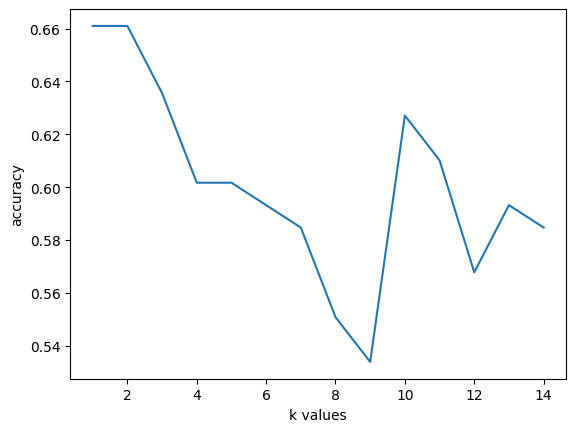

In [44]:
score_list=[]
for each in range(1,15):
    knn2=KNeighborsClassifier(n_neighbors=each)
    knn2.fit(x_train,y_train)
    score_list.append(knn2.score(x_test,y_test))

plt.plot(range(1,15),score_list)
plt.xlabel('k values')
plt.ylabel('accuracy')
plt.show()

como pudimos ver antes el accuracy fue 63,55%. Con su mayor valor cuando k = 1 obteniendo cerca de 66%

Naive bayes


In [45]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
print('nb accuracy : ', nb.score(x_test,y_test))

# confisuon matrix
y_pred = nb.predict(x_test)
y_pred_nb = y_pred
y_true = y_test
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_true,y_pred)
print('Matriz de Confusión:')
print(cm_nb)

nb accuracy :  0.923728813559322
Matriz de Confusión:
[[63  5]
 [ 4 46]]


en naive bayes la precisión es muchisimo mayor, de 92% aprox. Y esto se visualiza claramente en las siguientes matrices de confusión

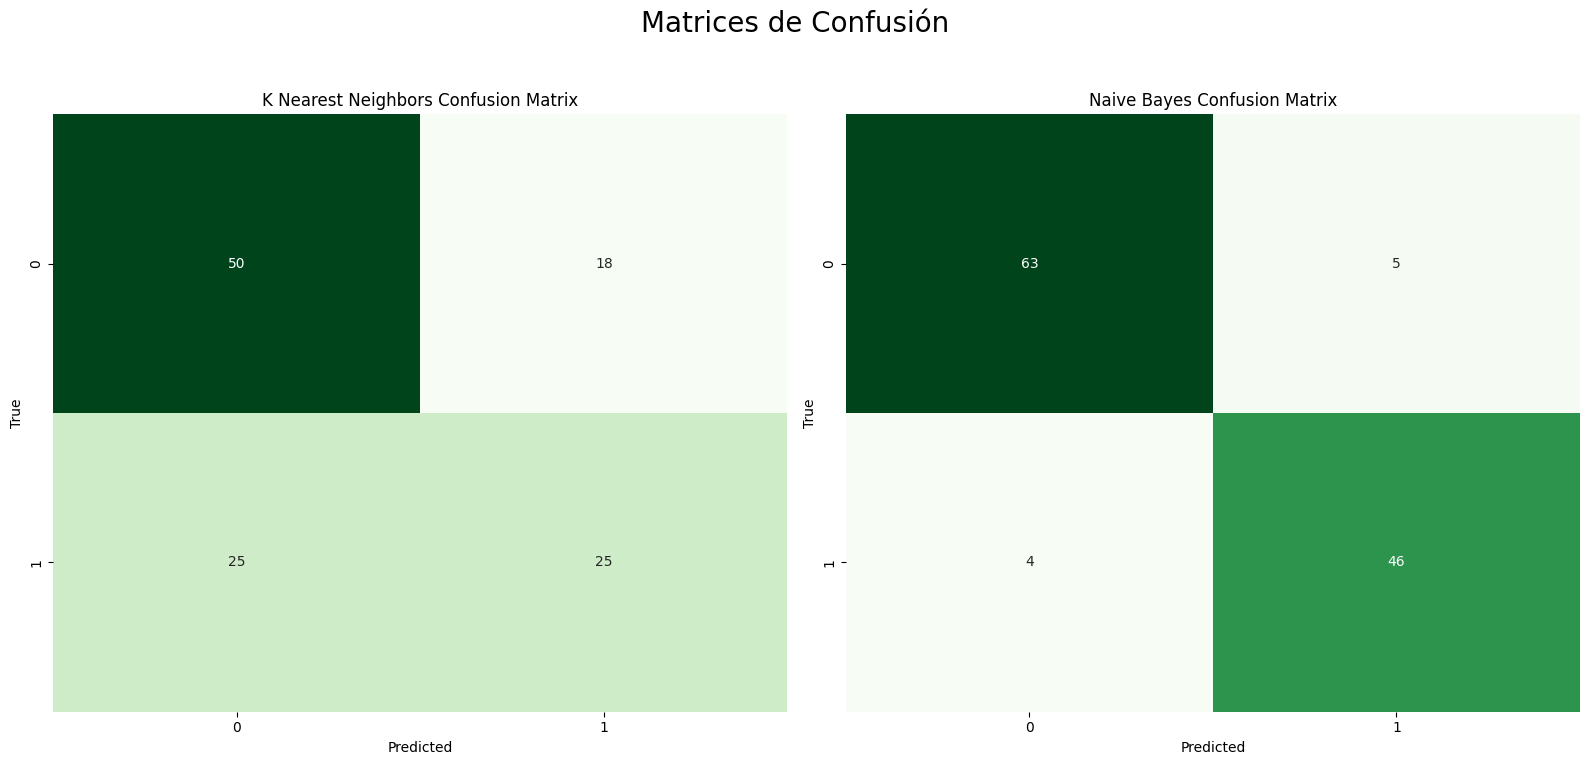

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 8)) # Create a 1x2 grid of subplots
fig.suptitle("Matrices de Confusión", fontsize=20) # Set suptitle on the figure

# Plot for K Nearest Neighbors Confusion Matrix
sns.heatmap(cm_knn, cbar=False, annot=True, cmap="Greens", fmt="d", ax=axes[0])
axes[0].set_title("K Nearest Neighbors Confusion Matrix")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Plot for Naive Bayes Confusion Matrix
sns.heatmap(cm_nb, cbar=False, annot=True, cmap="Greens", fmt="d", ax=axes[1])
axes[1].set_title("Naive Bayes Confusion Matrix")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping, leaving space for suptitle
plt.show()

Como podemos ver naive bayes tuvo mucho menos falsos de ambos. O sea la gran mayoria de veces que predijo lo hizo correctamente.

In [47]:
from sklearn.metrics import classification_report

# Obtén el informe de métricas para cada modelo
report_knn = classification_report(y_true, y_pred_knn)
report_nb = classification_report(y_true, y_pred_nb)

# Imprime los informes de métricas

print("\nK Nearest Neighbors Classification Report:")
print(report_knn)

print("\nNaive Bayes Classification Report:")
print(report_nb)



K Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70        68
           1       0.58      0.50      0.54        50

    accuracy                           0.64       118
   macro avg       0.62      0.62      0.62       118
weighted avg       0.63      0.64      0.63       118


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93        68
           1       0.90      0.92      0.91        50

    accuracy                           0.92       118
   macro avg       0.92      0.92      0.92       118
weighted avg       0.92      0.92      0.92       118



# 7.- Hiper parametros

KNN Gridsearch

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn_params = {'n_neighbors' : range(1,10),
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto','ball_tree','kd_tree','brute'],
              'p' : [1,2]
   }
knn=KNeighborsClassifier()

# Initialize accuracies dictionary if it doesn't exist
if 'accuracies' not in locals():
    accuracies = {}

knn_gridcv_model=GridSearchCV(estimator=knn, param_grid=knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=2).fit(x_train,y_train)
print(knn_gridcv_model.best_params_)
print('KNN GridSearch Model accuracy score = {}'.format(knn_gridcv_model.best_score_))
acc=knn_gridcv_model.best_score_ *100
accuracies['KNN Gridsearch']=acc

Fitting 5 folds for each of 144 candidates, totalling 720 fits


INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:04] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:04] "GET /_dash-component-suites/dash_bootstrap_components/_components/dash_bootstrap_components.v2_0_4m1782312483.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:04] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_3_0m1782312483.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:05] "GET /_dash-component-suites/dash/html/dash_html_components.v4_3_0m1782312483.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:04] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_3_0m1782312483.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:05] "GET /_dash-component-suites/dash/dash_table/bundle.v7_3_0m1782312483.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Jun/2026 14:49:05] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_3_0m1782312483.min.js HTTP/1.1" 

{'algorithm': 'auto', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
KNN GridSearch Model accuracy score = 0.6995959595959597


KNN Cross Validation

In [49]:
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier

kfold=model_selection.KFold(n_splits=5)
modelL=KNeighborsClassifier(n_neighbors= 1)
results=model_selection.cross_val_score(modelL,X,y,cv=kfold)
print(results)
print(results.mean()*100)
mean=results.mean()*100
accuracies['KNN CV']=mean

[0.65822785 0.66666667 0.74358974 0.56410256 0.65384615]
65.72865952612787


Naive bayes Gridsearch

In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GaussianNB (var_smoothing is a common parameter)
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

nb = GaussianNB()

# Initialize GridSearchCV
nb_gridcv_model = GridSearchCV(estimator=nb, param_grid=nb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=2).fit(x_train, y_train)

print(nb_gridcv_model.best_params_)
print('Naive Bayes GridSearch Model accuracy score = {}'.format(nb_gridcv_model.best_score_))

acc_nb = nb_gridcv_model.best_score_ * 100
accuracies['Naive Bayes Gridsearch'] = acc_nb


Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'var_smoothing': 1e-09}
Naive Bayes GridSearch Model accuracy score = 0.8972390572390573


Naive Bayes Cross Validation

In [51]:
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB # Import GaussianNB

kfold = model_selection.KFold(n_splits=5)
modelNB = GaussianNB() # Create an instance of GaussianNB
results_nb = model_selection.cross_val_score(modelNB, X, y, cv=kfold)
print(results_nb)
print(results_nb.mean() * 100)
mean_nb = results_nb.mean() * 100
accuracies['Naive Bayes CV'] = mean_nb # Store in accuracies dictionary

[0.96202532 0.93589744 0.91025641 0.96153846 0.93589744]
94.11230120090879


Comparación de con hiper parametros y sin hiperparametros

In [52]:
import collections

# Eliminar el valor 'KNN' si existe
if 'KNN' in accuracies:
    del accuracies['KNN']

# Definir el nuevo orden deseado
new_order = ['KNN Gridsearch', 'KNN CV', 'Naive Bayes Gridsearch', 'Naive Bayes CV']

# Crear un nuevo diccionario ordenado
ordered_accuracies = collections.OrderedDict()
for key in new_order:
    if key in accuracies: # Asegurarse de que la clave exista antes de añadirla
        ordered_accuracies[key] = accuracies[key]

# Reemplazar el diccionario original con el ordenado
accuracies = ordered_accuracies

# Display all accuracies collected so far
display(accuracies)

OrderedDict([('KNN Gridsearch', np.float64(69.95959595959597)),
             ('KNN CV', np.float64(65.72865952612787)),
             ('Naive Bayes Gridsearch', np.float64(89.72390572390573)),
             ('Naive Bayes CV', np.float64(94.11230120090879))])

In [53]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import plotly.express as px

# Re-initialize and fit KNN without hyperparameters for comparison
knn_base = KNeighborsClassifier(n_neighbors=3) # Using n_neighbors=3 as in cell ZwO7pCmOzCQ4
knn_base.fit(x_train, y_train)
knn_no_hp_accuracy = knn_base.score(x_test, y_test) * 100

# Re-initialize and fit Naive Bayes without hyperparameters for comparison
nb_base = GaussianNB()
nb_base.fit(x_train, y_train)
nb_no_hp_accuracy = nb_base.score(x_test, y_test) * 100

# Create a dictionary for all comparisons, assuming 'accuracies' is already populated
comparison_accuracies = {
    'KNN sin hiperparametros': knn_no_hp_accuracy,
    'Naive Bayes sin hiperparametros': nb_no_hp_accuracy,
    'KNN Gridsearch': accuracies['KNN Gridsearch'],
    'Naive Bayes Gridsearch': accuracies['Naive Bayes Gridsearch'],
    'KNN CV': accuracies['KNN CV'],
    'Naive Bayes CV': accuracies['Naive Bayes CV']
}

# Convert to a DataFrame for better display and sorting
df_comparison = pd.DataFrame(comparison_accuracies.items(), columns=['Modelo', 'Precision (%)'])
df_comparison = df_comparison.sort_values(by='Precision (%)', ascending=False).reset_index(drop=True)

display(df_comparison)

# Plotting the comparison
fig_comparison = px.bar(
    df_comparison,
    x='Modelo',
    y='Precision (%)',
    color='Precision (%)',
    text='Precision (%)',
    color_continuous_scale='Viridis',
    title='Comparación de Precisiones de Modelos'
)
fig_comparison.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig_comparison.update_layout(
    xaxis_title='Modelo',
    yaxis_title='Precisión (%)',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)
fig_comparison.show()

,Modelo,Precision (%)
0,Naive Bayes CV,94.112301
1,Naive Bayes sin hiperparametros,92.372881
2,Naive Bayes Gridsearch,89.723906
3,KNN Gridsearch,69.959596
4,KNN CV,65.728660
5,KNN sin hiperparametros,63.559322


Para este dataframe, el modelo más preciso para predecir futuras empresas distribuidoras es Naive Bayes con su ajuste de hipeparametros en Cross validation. El peor o menos preciso es el KNN sin hiperparametros